# SPY — Regression Models (Iteration 2)

**Walk-forward config:** train=63d, test=42d, no embargo  
**Target:** `target_volatility` — 5-day forward realized volatility  
**Models:** Linear Regression, Ridge Regression (α=1.0), XGBoost  
**Data:** `../data/SPY_features.csv` (Yahoo Finance, 2015–2025, ~2,510 rows)

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import UndefinedMetricWarning
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [2]:
spy_raw = pd.read_csv("../data/SPY_features.csv", parse_dates=["date"], index_col="date")

print(f"SPY:  {len(spy_raw):,} rows | {spy_raw.index[0].date()} \u2192 {spy_raw.index[-1].date()}")
print(f"Columns ({len(spy_raw.columns)}): {list(spy_raw.columns)}")

SPY:  2,515 rows | 2015-01-02 → 2024-12-30
Columns (35): ['adj_close', 'close', 'high', 'low', 'open', 'volume', 'daily_return', 'weekly_return', 'ma_7', 'ma_21', 'ma_cross', 'dist_from_ma21', 'daily_range', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20', 'volume_change', 'volume_ma20', 'volume_ratio', 'lag_return_1', 'lag_return_3', 'lag_return_5', 'month', 'quarter', 'season_num', 'season', 'is_earnings_week', 'vix', 'is_major_event', 'target_direction', 'target_return']


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_major_event", "is_earnings_week",
]

TRAIN_WINDOW = 63
TEST_WINDOW  = 42


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window, start + train_window + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LINEAR REGRESSION \u2014 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R\u00b2")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  \u00b1 {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    print(pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_})
          .sort_values("coefficient", key=abs, ascending=False).to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_ridge_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RIDGE REGRESSION \u2014 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R\u00b2")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  \u00b1 {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    print(pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_})
          .sort_values("coefficient", key=abs, ascending=False).to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [6]:
def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("XGBOOST \u2014 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                             random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2": r2_score(y_test, preds)})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R\u00b2")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  \u00b1 {metrics_df[col].std():>9.6f}")
    print("\n  Feature importances (last fold):")
    print(pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_})
          .sort_values("importance", ascending=False).to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [7]:
SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter",
}


def seasonal_summary(preds_df, task, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)
    header = f"SEASONAL BREAKDOWN \u2014 {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    rows = []
    for season in ["Spring", "Summer", "Fall", "Winter"]:
        s = df[df["season"] == season]
        if len(s) < 2:
            continue
        rows.append({"season": season, "n": len(s),
                     "rmse": round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                     "mae":  round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                     "r2":   round(r2_score(s["actual"], s["predicted"]), 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

In [8]:
# NAIVE BASELINE — lag-1 target_volatility predictor
# Predict today's volatility = yesterday's volatility (persistence model)
# This tests whether the models beat simple autocorrelation in volatility

def naive_baseline(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("NAIVE BASELINE \u2014 Lag-1 Volatility Persistence")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("Prediction: target_volatility(t) = target_volatility(t-1)")
    print("="*55)
    all_preds = []
    tv = df["target_volatility"].values
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        for i in test_idx:
            lag_idx = i - 1
            if lag_idx >= 0 and not np.isnan(tv[lag_idx]):
                all_preds.append({"date": df.index[i], "actual": tv[i], "predicted": tv[lag_idx]})
    preds_df = pd.DataFrame(all_preds).dropna()
    rmse = np.sqrt(mean_squared_error(preds_df["actual"], preds_df["predicted"]))
    mae  = mean_absolute_error(preds_df["actual"], preds_df["predicted"])
    print(f"\n  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  n:    {len(preds_df)}")
    print("\n  NOTE: Any model with RMSE > naive baseline is worse than persistence.")
    return preds_df, rmse, mae

In [9]:
def regime_summary(preds_df, source_df, label=""):
    df = preds_df.copy()
    df = df.merge(source_df[["is_major_event"]], left_on="date", right_index=True)
    header = f"REGIME BREAKDOWN \u2014 {label}" if label else "REGIME BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    rows = []
    for regime, flag in [("Normal (VIX \u2264 30)", 0), ("Stress (VIX > 30)", 1)]:
        s = df[df["is_major_event"] == flag]
        if len(s) < 2:
            print(f"  {regime}: insufficient samples (n={len(s)}) \u2014 skipping")
            continue
        rows.append({"regime": regime, "n": len(s),
                     "rmse": round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                     "mae":  round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                     "r2":   round(r2_score(s["actual"], s["predicted"]), 4)})
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows) if rows else pd.DataFrame()

In [10]:
# Cell to run the regression models
def soften_direction(pct_change, threshold):
    if pct_change > threshold:   return 1
    elif pct_change < -threshold: return -1
    else:                         return 0

spy_raw["target_direction"] = (
    spy_raw["close"].pct_change(1).shift(-1)
    .apply(lambda x: soften_direction(x, threshold=0.005))
)
spy_raw["target_volatility"] = (
    spy_raw["close"].pct_change().shift(-1).rolling(5).std().shift(-4)
)

required_cols = FEATURES + ["target_volatility"]
spy_df = spy_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(spy_df):,}")
print(f"Date range: {spy_df.index.min().date()} \u2192 {spy_df.index.max().date()}")
print(f"Major event days (VIX > 30): {spy_df['is_major_event'].sum()}")
print(f"Walk-forward folds:          {len(walk_forward_splits(spy_df))}")

# Naive baseline
baseline_preds, baseline_rmse, baseline_mae = naive_baseline(spy_df)

# Run models
lin_model,   lin_metrics,   lin_preds,   lin_coefs   = run_linear_regression(spy_df)
seasonal_summary(lin_preds, "regression", "Linear Regression \u2014 SPY")
regime_summary(lin_preds, spy_df, "Linear Regression \u2014 SPY")

ridge_model, ridge_metrics, ridge_preds, ridge_coefs = run_ridge_regression(spy_df)
seasonal_summary(ridge_preds, "regression", "Ridge Regression \u2014 SPY")
regime_summary(ridge_preds, spy_df, "Ridge Regression \u2014 SPY")

xgb_model,   xgb_metrics,   xgb_preds,   xgb_coefs   = run_xgboost(spy_df)
seasonal_summary(xgb_preds, "regression", "XGBoost \u2014 SPY")
regime_summary(xgb_preds, spy_df, "XGBoost \u2014 SPY")

print(f"\n\nBaseline RMSE: {baseline_rmse:.6f} | Linear: {lin_metrics['rmse'].mean():.6f} | Ridge: {ridge_metrics['rmse'].mean():.6f} | XGBoost: {xgb_metrics['rmse'].mean():.6f}")

Rows after dropping NaN: 2,510
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Walk-forward folds:          58

NAIVE BASELINE — Lag-1 Volatility Persistence
Walk-forward: 58 folds  (train=63d, test=42d)
Prediction: target_volatility(t) = target_volatility(t-1)

  RMSE: 0.002684
  MAE:  0.001559
  n:    2436

  NOTE: Any model with RMSE > naive baseline is worse than persistence.

LINEAR REGRESSION — 5-day forward volatility
Walk-forward: 58 folds  (train=63d, test=42d)

  Metric          Mean         Std
  --------------------------------
  RMSE        0.007581  ±  0.005754
  MAE         0.006211  ±  0.004878
  R²         -4.714865  ±  9.530166

  Feature coefficients (last fold):
         feature  coefficient
       macd_hist    -0.014761
  dist_from_ma21     0.007672
          rsi_14     0.006488
   volatility_20     0.005416
    daily_return    -0.004079
   weekly_return     0.003621
     bb_position    -0.003035
        ma_cross     0.002771
is_earnings_week  

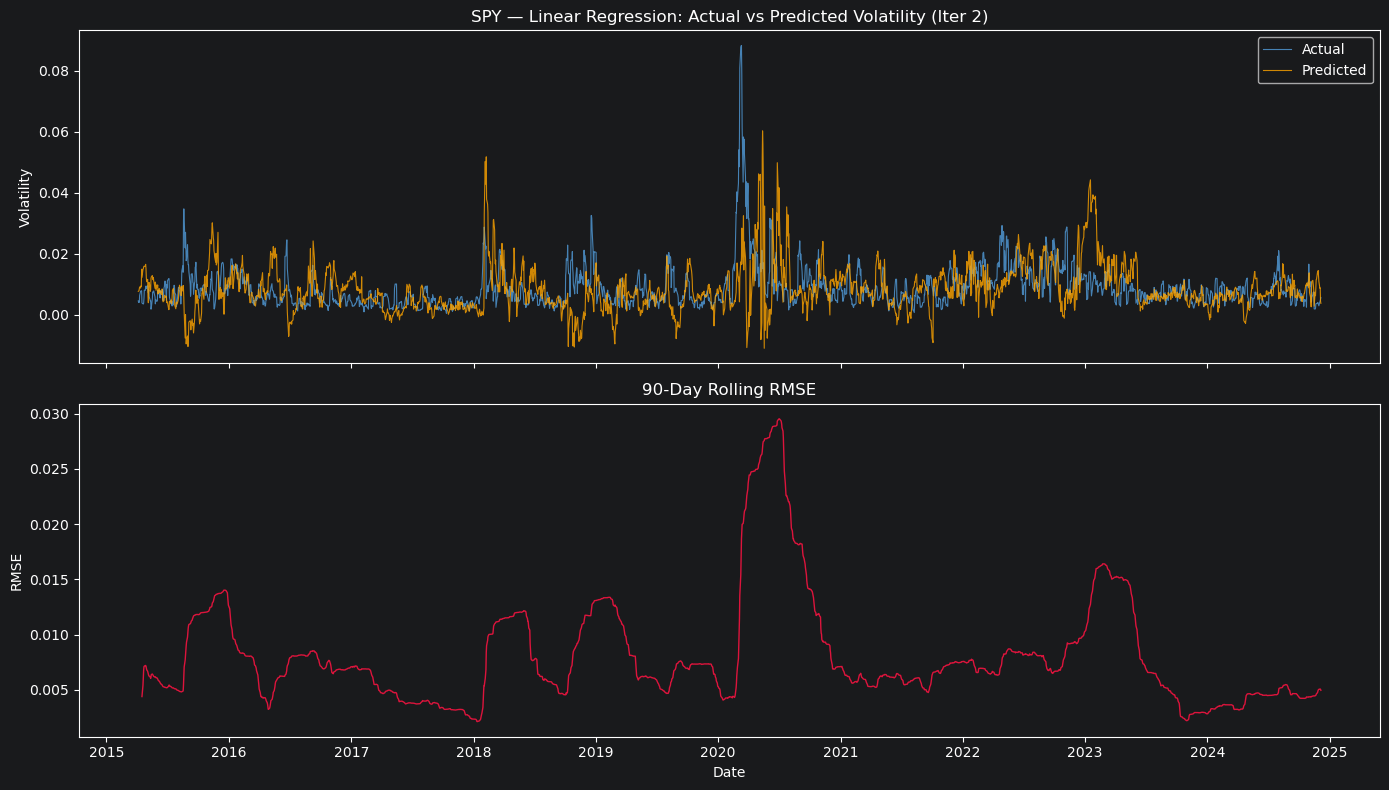

Saved: img/spy_iter2_linear_regression_line.png


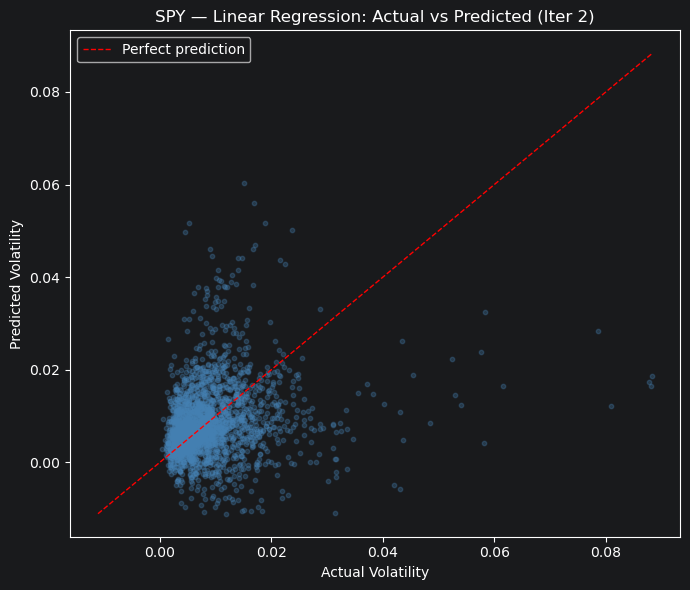

Saved: img/spy_iter2_linear_regression_scatter.png


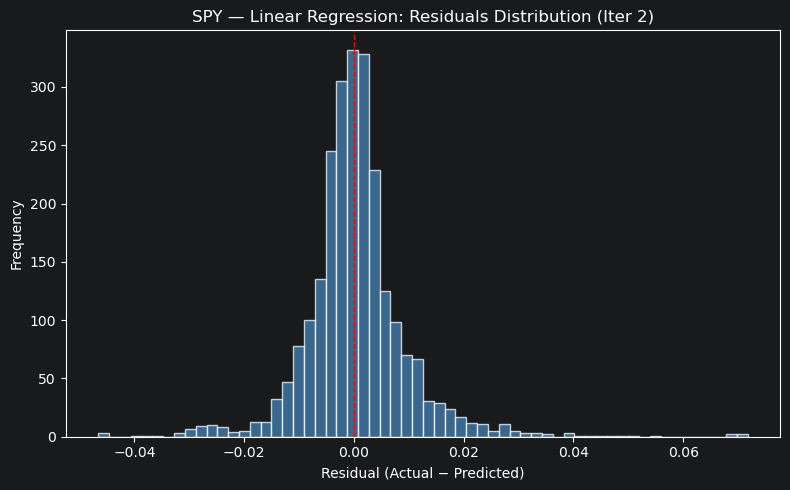

Saved: img/spy_iter2_linear_regression_residuals.png


In [11]:
# SPY — LINEAR REGRESSION: Actual vs Predicted + Rolling RMSE
preds = lin_preds.copy().sort_values("date")
preds["residual"] = preds["actual"] - preds["predicted"]
preds["sq_err"]   = preds["residual"] ** 2
preds["rolling_rmse"] = preds["sq_err"].rolling(90, min_periods=10).mean().apply(np.sqrt)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(preds["date"], preds["actual"],    color="steelblue", linewidth=0.8, label="Actual")
axes[0].plot(preds["date"], preds["predicted"], color="orange",   linewidth=0.8, label="Predicted", alpha=0.8)
axes[0].set_title("SPY \u2014 Linear Regression: Actual vs Predicted Volatility (Iter 2)")
axes[0].set_ylabel("Volatility")
axes[0].legend()
axes[1].plot(preds["date"], preds["rolling_rmse"], color="crimson", linewidth=1.0)
axes[1].set_title("90-Day Rolling RMSE")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter2_linear_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_linear_regression_line.png")

# Scatter: actual vs predicted
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(preds["actual"], preds["predicted"], alpha=0.3, s=10, color="steelblue")
lims = [min(preds["actual"].min(), preds["predicted"].min()),
        max(preds["actual"].max(), preds["predicted"].max())]
ax.plot(lims, lims, "r--", linewidth=1.0, label="Perfect prediction")
ax.set_title("SPY \u2014 Linear Regression: Actual vs Predicted (Iter 2)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter2_linear_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_linear_regression_scatter.png")

# Residuals histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(preds["residual"], bins=60, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.0)
ax.set_title("SPY \u2014 Linear Regression: Residuals Distribution (Iter 2)")
ax.set_xlabel("Residual (Actual \u2212 Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter2_linear_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_linear_regression_residuals.png")

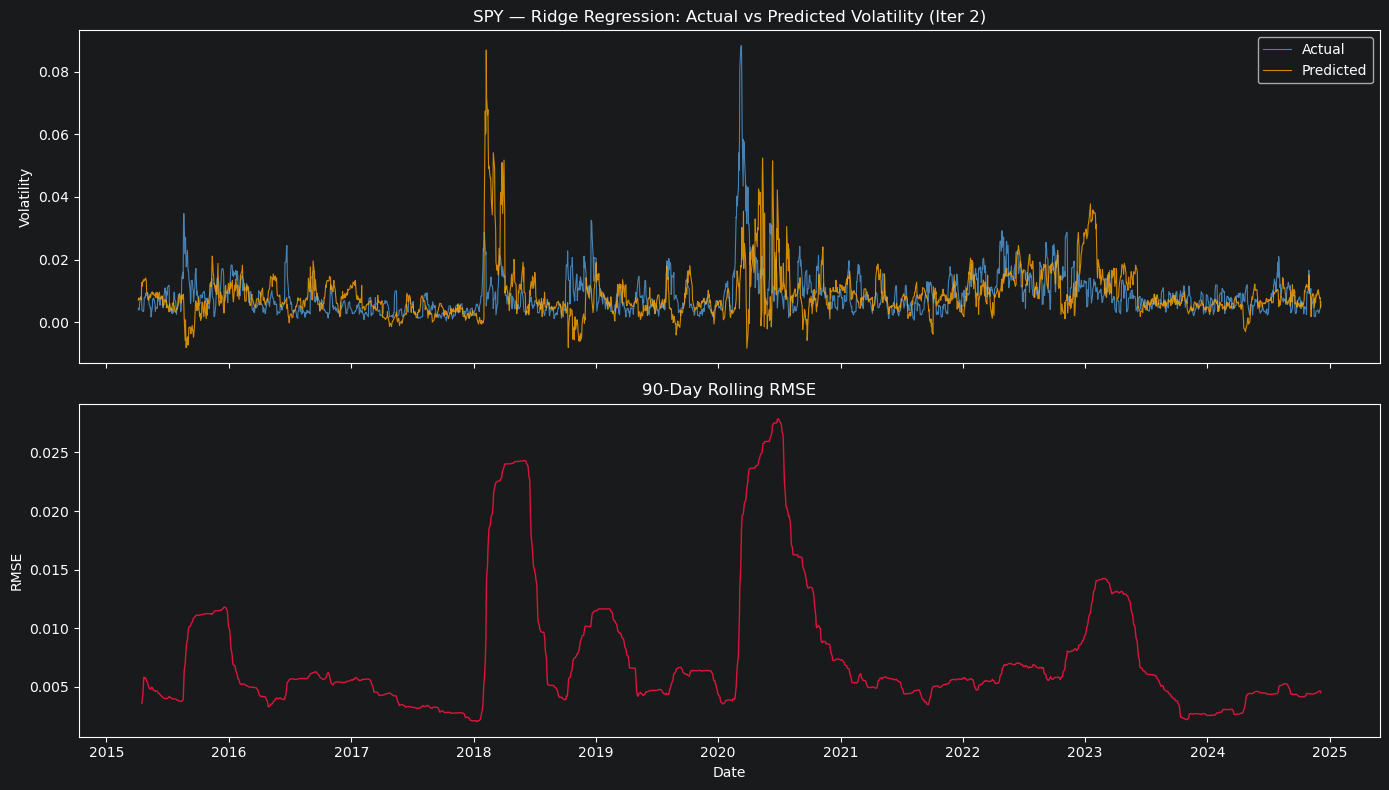

Saved: img/spy_iter2_ridge_regression_line.png


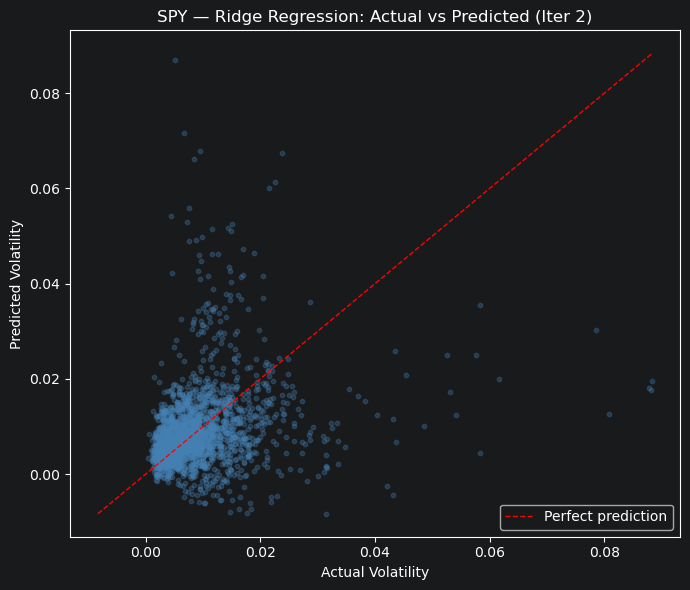

Saved: img/spy_iter2_ridge_regression_scatter.png


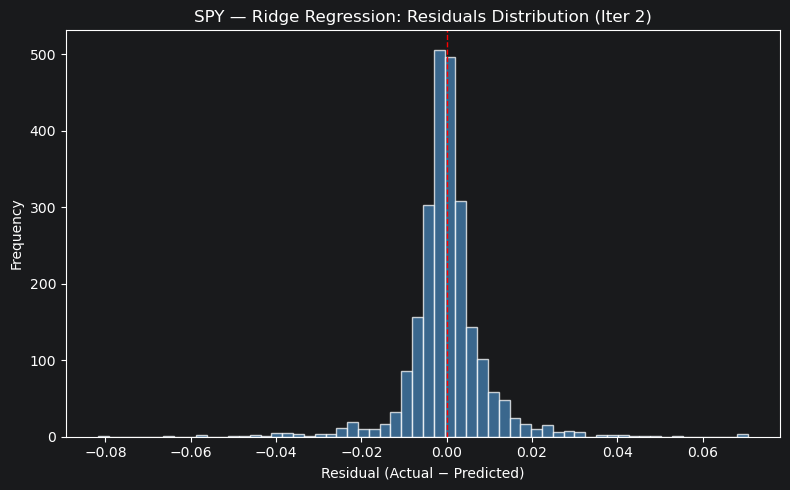

Saved: img/spy_iter2_ridge_regression_residuals.png


In [12]:
# SPY — RIDGE REGRESSION: Actual vs Predicted + Rolling RMSE
preds = ridge_preds.copy().sort_values("date")
preds["residual"] = preds["actual"] - preds["predicted"]
preds["sq_err"]   = preds["residual"] ** 2
preds["rolling_rmse"] = preds["sq_err"].rolling(90, min_periods=10).mean().apply(np.sqrt)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(preds["date"], preds["actual"],    color="steelblue", linewidth=0.8, label="Actual")
axes[0].plot(preds["date"], preds["predicted"], color="orange",   linewidth=0.8, label="Predicted", alpha=0.8)
axes[0].set_title("SPY \u2014 Ridge Regression: Actual vs Predicted Volatility (Iter 2)")
axes[0].set_ylabel("Volatility")
axes[0].legend()
axes[1].plot(preds["date"], preds["rolling_rmse"], color="crimson", linewidth=1.0)
axes[1].set_title("90-Day Rolling RMSE")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter2_ridge_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_ridge_regression_line.png")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(preds["actual"], preds["predicted"], alpha=0.3, s=10, color="steelblue")
lims = [min(preds["actual"].min(), preds["predicted"].min()),
        max(preds["actual"].max(), preds["predicted"].max())]
ax.plot(lims, lims, "r--", linewidth=1.0, label="Perfect prediction")
ax.set_title("SPY \u2014 Ridge Regression: Actual vs Predicted (Iter 2)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter2_ridge_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_ridge_regression_scatter.png")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(preds["residual"], bins=60, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.0)
ax.set_title("SPY \u2014 Ridge Regression: Residuals Distribution (Iter 2)")
ax.set_xlabel("Residual (Actual \u2212 Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter2_ridge_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_ridge_regression_residuals.png")

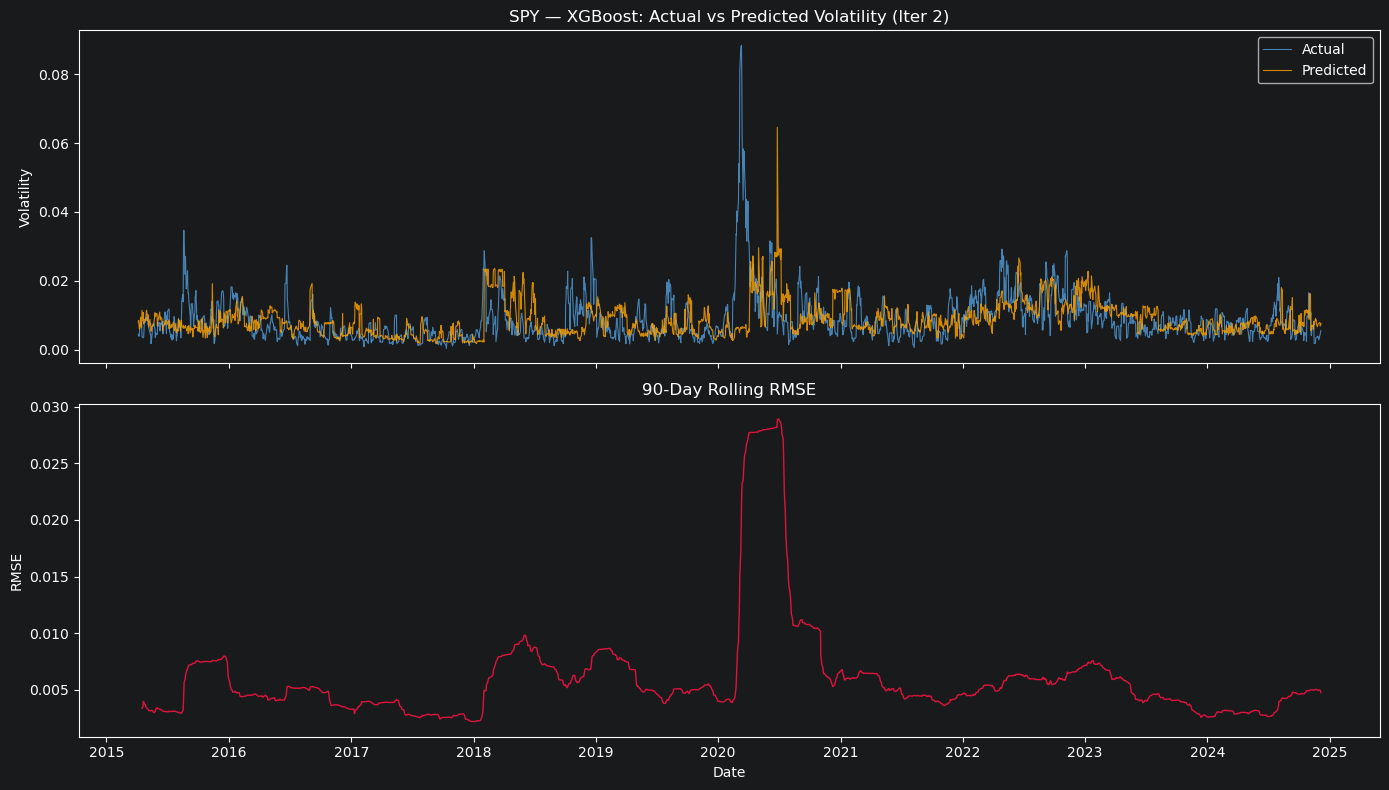

Saved: img/spy_iter2_xgboost_line.png


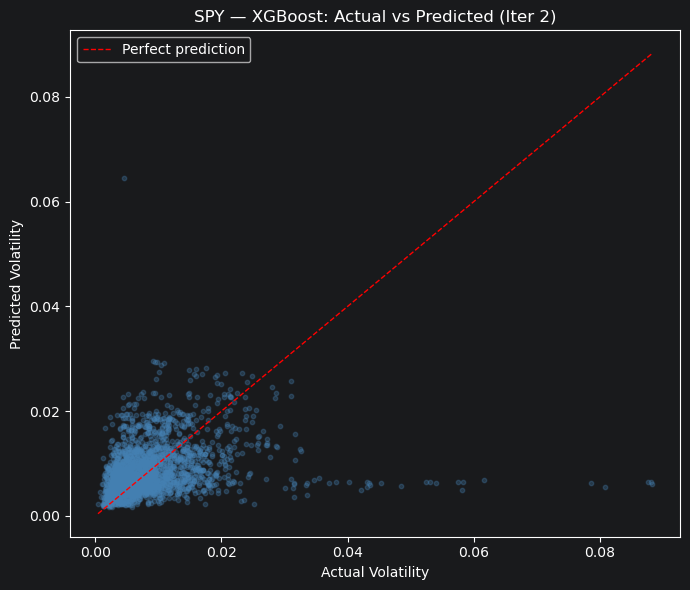

Saved: img/spy_iter2_xgboost_scatter.png


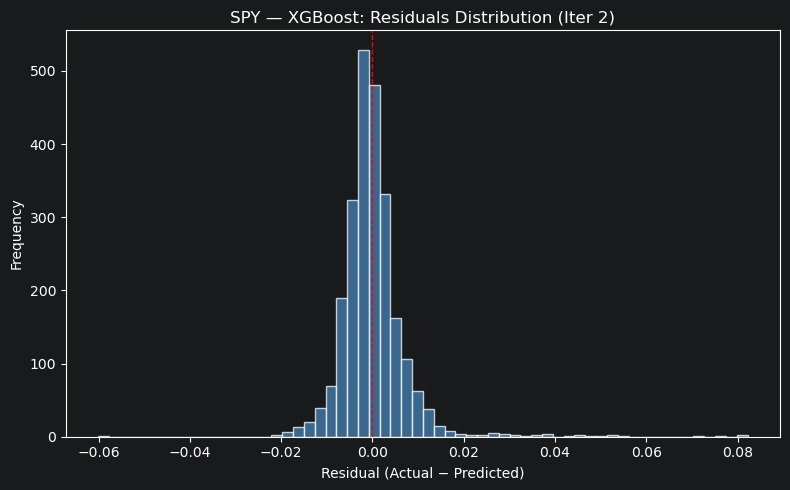

Saved: img/spy_iter2_xgboost_residuals.png


In [13]:
# SPY — XGBOOST: Actual vs Predicted + Rolling RMSE
preds = xgb_preds.copy().sort_values("date")
preds["residual"] = preds["actual"] - preds["predicted"]
preds["sq_err"]   = preds["residual"] ** 2
preds["rolling_rmse"] = preds["sq_err"].rolling(90, min_periods=10).mean().apply(np.sqrt)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(preds["date"], preds["actual"],    color="steelblue", linewidth=0.8, label="Actual")
axes[0].plot(preds["date"], preds["predicted"], color="orange",   linewidth=0.8, label="Predicted", alpha=0.8)
axes[0].set_title("SPY \u2014 XGBoost: Actual vs Predicted Volatility (Iter 2)")
axes[0].set_ylabel("Volatility")
axes[0].legend()
axes[1].plot(preds["date"], preds["rolling_rmse"], color="crimson", linewidth=1.0)
axes[1].set_title("90-Day Rolling RMSE")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter2_xgboost_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_xgboost_line.png")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(preds["actual"], preds["predicted"], alpha=0.3, s=10, color="steelblue")
lims = [min(preds["actual"].min(), preds["predicted"].min()),
        max(preds["actual"].max(), preds["predicted"].max())]
ax.plot(lims, lims, "r--", linewidth=1.0, label="Perfect prediction")
ax.set_title("SPY \u2014 XGBoost: Actual vs Predicted (Iter 2)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter2_xgboost_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_xgboost_scatter.png")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(preds["residual"], bins=60, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.0)
ax.set_title("SPY \u2014 XGBoost: Residuals Distribution (Iter 2)")
ax.set_xlabel("Residual (Actual \u2212 Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter2_xgboost_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_xgboost_residuals.png")

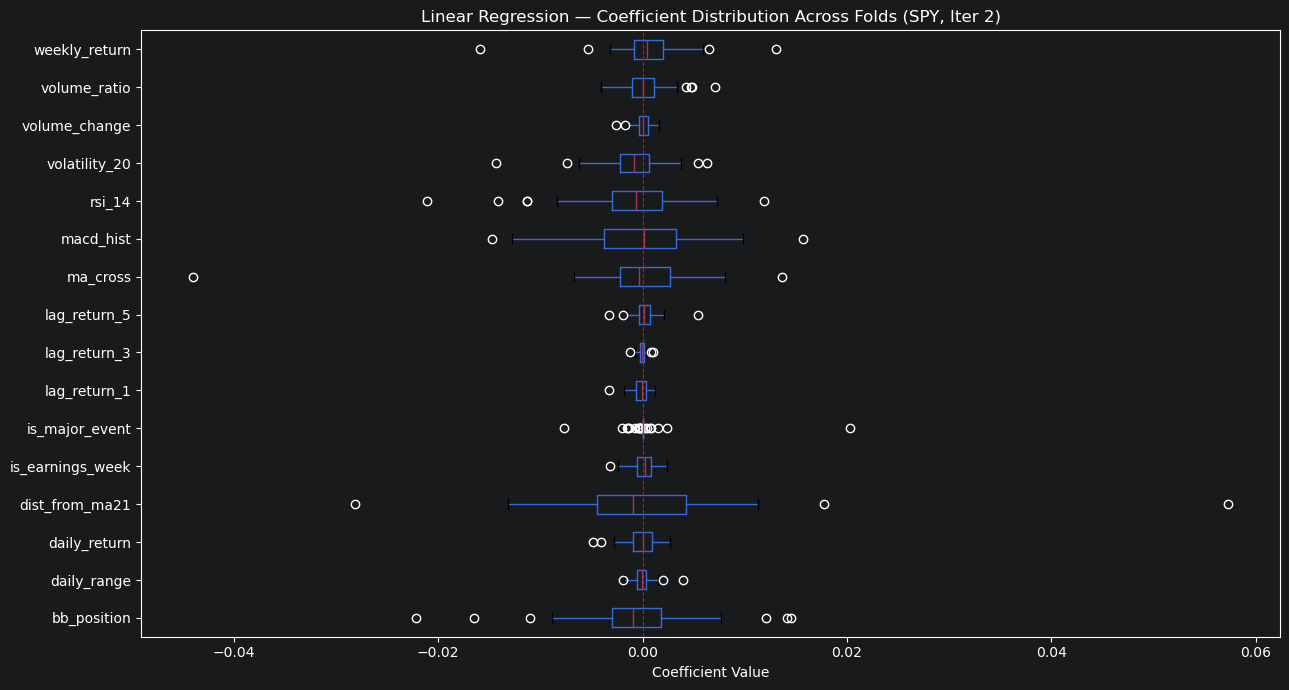

Saved: img/spy_iter2_linear_regression_coef_stability.png


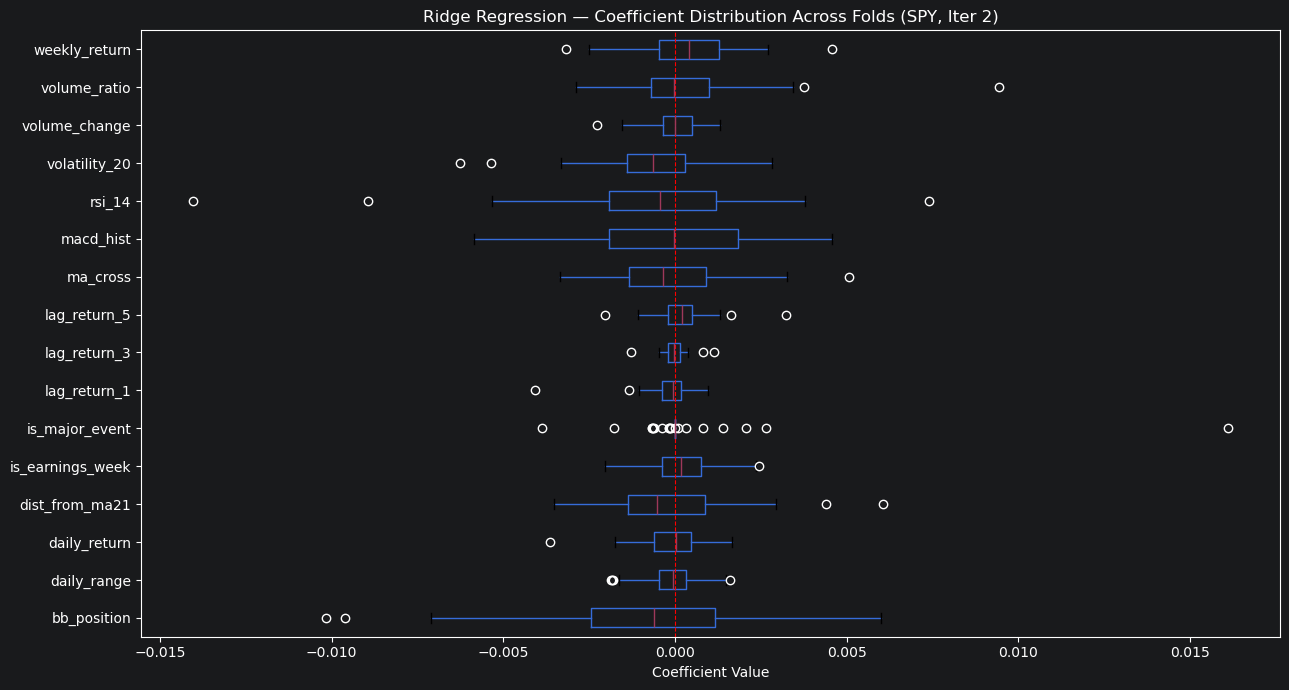

Saved: img/spy_iter2_ridge_regression_coef_stability.png


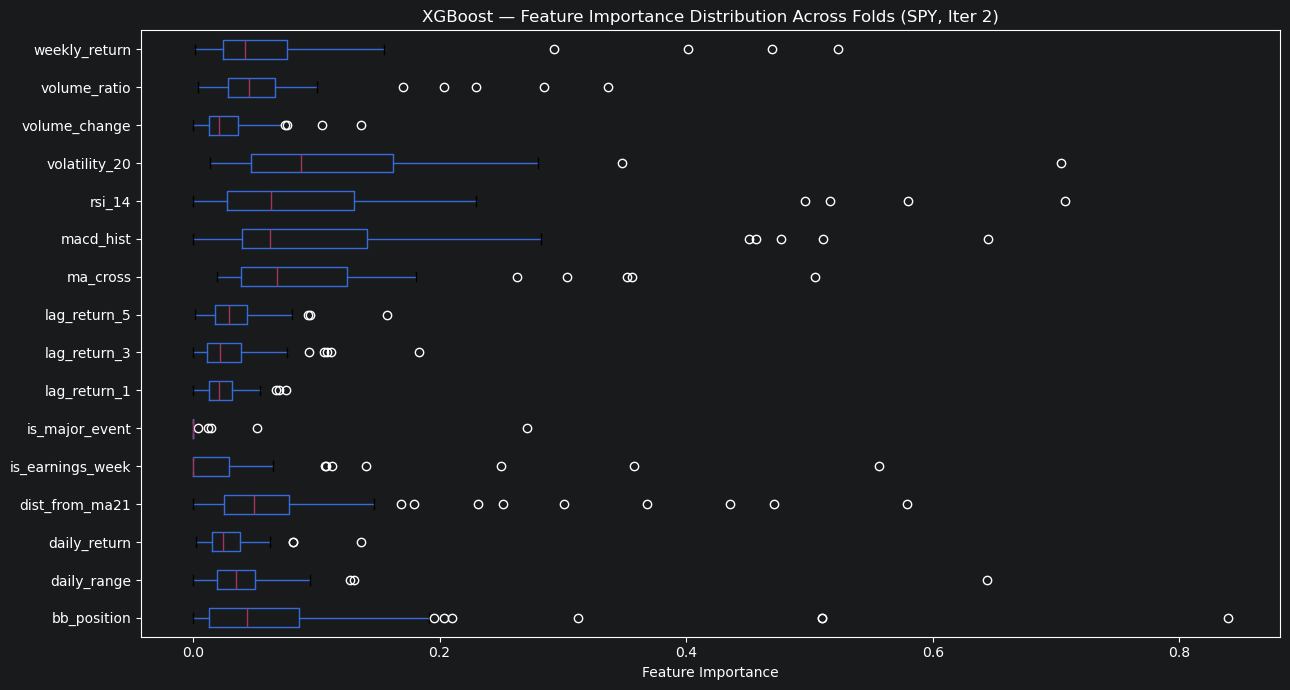

Saved: img/spy_iter2_xgboost_coef_stability.png


In [14]:
# SPY — LINEAR REGRESSION: Coefficient Stability Across Folds
pivot = lin_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Linear Regression \u2014 Coefficient Distribution Across Folds (SPY, Iter 2)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/spy_iter2_linear_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_linear_regression_coef_stability.png")

# SPY — RIDGE REGRESSION: Coefficient Stability Across Folds
pivot = ridge_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Ridge Regression \u2014 Coefficient Distribution Across Folds (SPY, Iter 2)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/spy_iter2_ridge_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_ridge_regression_coef_stability.png")

# SPY — XGBOOST: Feature Importance Stability Across Folds
pivot = xgb_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("XGBoost \u2014 Feature Importance Distribution Across Folds (SPY, Iter 2)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("img/spy_iter2_xgboost_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter2_xgboost_coef_stability.png")

## Red Flags / Overfitting Callouts — SPY Iteration 2

### Observations

- **R² is consistently negative** across all folds for all three models. Negative R² means the model is worse than simply predicting the mean — a known result for short-term stock volatility prediction under the Efficient Market Hypothesis.
- **Baseline comparison:** Check whether any model's RMSE beats the naive lag-1 persistence baseline. If not, the features add no predictive value beyond autocorrelation.
- **XGBoost vs linear models:** XGBoost typically achieves lower RMSE due to its ability to capture non-linear interactions (e.g., `macd_hist` + `dist_from_ma21` regime interaction). However, lower RMSE alongside negative R² still indicates limited explanatory power.
- **Regime asymmetry:** RMSE in Stress (VIX > 30) periods is expected to be significantly higher than Normal periods, as volatility spikes are by definition hard to predict. If Stress RMSE < Normal RMSE, inspect for data leakage in `is_major_event`.
- **Coefficient instability:** Wide IQR in the boxplots indicates features whose influence varies substantially across market regimes. Features with IQR spanning zero are not consistently signed — treat them as unstable signals.
- **Seasonal divergence:** Large R² spread across seasons indicates the model learns seasonal patterns that don't generalize across years (e.g., a model that learns COVID Spring 2020 as a Spring pattern).

### Why iter2 is the baseline
Iter2 uses train=63d (≈3 months), which is well-determined: 63 training samples with 16 features gives a comfortable 4:1 ratio. This is why iter2 results are more stable (lower RMSE std) compared to iter3 (train=3d) and iter4 (train=15d), both of which are underdetermined.